In [8]:
# import random
# import numpy as np

# # =========================
# # Objective Function
# # =========================
# def objective_function(x):
#     return np.sum(x**2)

# # =========================
# # PSO Algorithm
# # =========================
# def pso(
#     obj_func,
#     dim,
#     bounds,
#     num_particles=30,
#     max_iter=100,
#     w=0.7,
#     c1=1.5,
#     c2=1.5
# ):
#     # Initialize particles
#     particles = np.random.uniform(
#         low=[b[0] for b in bounds],
#         high=[b[1] for b in bounds],
#         size=(num_particles, dim)
#     )

#     velocities = np.zeros((num_particles, dim))

#     pbest_positions = particles.copy()
#     pbest_scores = np.array([obj_func(p) for p in particles])

#     gbest_index = np.argmin(pbest_scores)
#     gbest_position = pbest_positions[gbest_index]
#     gbest_score = pbest_scores[gbest_index]

#     # Iteration
#     for iteration in range(max_iter):
#         for i in range(num_particles):
#             r1, r2 = random.random(), random.random()

#             velocities[i] = (
#                 w * velocities[i]
#                 + c1 * r1 * (pbest_positions[i] - particles[i])
#                 + c2 * r2 * (gbest_position - particles[i])
#             )

#             particles[i] += velocities[i]

#             # Boundary handling
#             for d in range(dim):
#                 particles[i, d] = np.clip(
#                     particles[i, d],
#                     bounds[d][0],
#                     bounds[d][1]
#                 )

#             score = obj_func(particles[i])

#             # Update pBest
#             if score < pbest_scores[i]:
#                 pbest_scores[i] = score
#                 pbest_positions[i] = particles[i]

#                 # Update gBest
#                 if score < gbest_score:
#                     gbest_score = score
#                     gbest_position = particles[i]

#         print(f"Iter {iteration+1}/{max_iter}, Best Score: {gbest_score}")

#     return gbest_position, gbest_score


# # =========================
# # Run PSO
# # =========================
# dimensions = 5
# bounds = [(-10, 10)] * dimensions

# best_position, best_value = pso(
#     objective_function,
#     dim=dimensions,
#     bounds=bounds
# )

# print("\nBest Solution:", best_position)
# print("Best Objective Value:", best_value)


In [9]:
import pandas as pd
df= pd.read_excel('Data_PT. Amanah_Critical_Break.xlsx')
# df = df[df['Status'].isin(["Critical", "Break"])]
df=df[df['Status']=="Critical"] 
df.head(15)

,Exhaust Gas Temperature LF (Left Front),Exhaust Gas Temperature LR (Left Rear),Exhaust Gas Temperature RF (Right Front),Exhaust Gas Temperature RR (Right Rear),Blowby Pressure (Kpa),Boost Pressure (Kpa),Engine Oil Temp (°C),Coolant Temp (°C),Unit Lifetime (Hour),Status,sisa jam
328,704.33,666.686,659.947,750,4.537,145.09,117.128,102.619,76473,Critical,2164.0
403,688.297,750,733.196,642.027,5.509,166.996,124.477,109.764,76548,Critical,2089.0
405,693.454,750,730.53,646.575,5.569,165.516,122.693,110,76550,Critical,2087.0
410,688.051,750,736.907,666.809,6.206,156.452,125.636,109.053,76555,Critical,2082.0
411,689.735,750,739.911,681.378,6.224,156.855,125.152,109.758,76556,Critical,2081.0
417,672.136,730.335,750,713.521,5.4,156.13,122.16,107.613,76562,Critical,2075.0
427,679.126,732.495,703.755,710.776,4.966,157.846,128,107.251,76572,Critical,2065.0
429,678.777,734.138,718.713,718.473,4.601,157.035,128,106.787,76574,Critical,2063.0
430,683.581,735.55,716.101,719.533,4.606,156.366,128,105.212,76575,Critical,2062.0
431,690.26,731.316,713.622,708.636,4.779,156.147,128,104.328,76576,Critical,2061.0


In [10]:
df=df.drop(columns='Status')
df=df.drop(columns='Unit Lifetime (Hour)')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 645 entries, 328 to 2491
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Exhaust Gas Temperature LF (Left Front)   645 non-null    object 
 1   Exhaust Gas Temperature LR (Left Rear)    645 non-null    object 
 2   Exhaust Gas Temperature RF (Right Front)  645 non-null    object 
 3   Exhaust Gas Temperature RR (Right Rear)   645 non-null    object 
 4   Blowby Pressure (Kpa)                     645 non-null    object 
 5   Boost Pressure (Kpa)                      645 non-null    object 
 6   Engine Oil Temp (°C)                      645 non-null    object 
 7   Coolant Temp (°C)                         645 non-null    object 
 8   sisa jam                                  645 non-null    float64
dtypes: float64(1), object(8)
memory usage: 50.4+ KB


In [12]:
df = df.astype({
    'Exhaust Gas Temperature LF (Left Front)': 'float',
    'Exhaust Gas Temperature LR (Left Rear)': 'float',
    'Exhaust Gas Temperature RF (Right Front)': 'float',
    'Exhaust Gas Temperature RR (Right Rear)': 'float',
    'Blowby Pressure (Kpa)': 'float',
    'Boost Pressure (Kpa)': 'float',
    'Engine Oil Temp (°C)': 'float',
    'Coolant Temp (°C)': 'float',
    
    'sisa jam':'float'
})

In [15]:
df_numeric = df.select_dtypes(include='number')
df_cor=df_numeric.corr()
df_cor

,Exhaust Gas Temperature LF (Left Front),Exhaust Gas Temperature LR (Left Rear),Exhaust Gas Temperature RF (Right Front),Exhaust Gas Temperature RR (Right Rear),Blowby Pressure (Kpa),Boost Pressure (Kpa),Engine Oil Temp (°C),Coolant Temp (°C),sisa jam
Exhaust Gas Temperature LF (Left Front),1.000000,0.248373,0.212556,0.274579,0.142789,0.192914,0.522617,-0.050117,-0.226660
Exhaust Gas Temperature LR (Left Rear),0.248373,1.000000,0.386200,0.126302,0.367202,0.254513,0.206661,0.010622,-0.140844
Exhaust Gas Temperature RF (Right Front),0.212556,0.386200,1.000000,0.186081,0.342510,0.118513,0.225955,-0.128078,-0.110807
Exhaust Gas Temperature RR (Right Rear),0.274579,0.126302,0.186081,1.000000,0.376737,0.281040,0.104738,-0.087277,-0.430794
Blowby Pressure (Kpa),0.142789,0.367202,0.342510,0.376737,1.000000,0.527649,0.169909,0.165723,-0.612148
Boost Pressure (Kpa),0.192914,0.254513,0.118513,0.281040,0.527649,1.000000,0.255485,0.510737,-0.673088
Engine Oil Temp (°C),0.522617,0.206661,0.225955,0.104738,0.169909,0.255485,1.000000,0.053889,-0.240445
Coolant Temp (°C),-0.050117,0.010622,-0.128078,-0.087277,0.165723,0.510737,0.053889,1.000000,-0.198657
sisa jam,-0.226660,-0.140844,-0.110807,-0.430794,-0.612148,-0.673088,-0.240445,-0.198657,1.000000


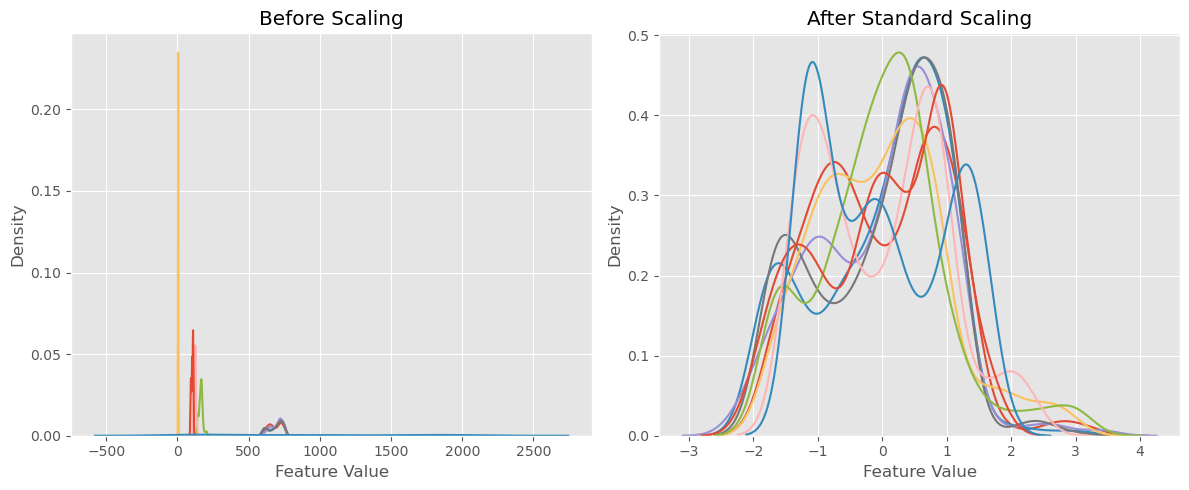

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = df

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

plt.style.use('ggplot')
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Sebelum Scaling 
for col in df.columns:
    sns.kdeplot(df[col], ax=axes[0], label=col)

axes[0].set_title('Before Scaling')
axes[0].set_xlabel('Feature Value')         
axes[0].set_ylabel('Density')               


# Setelah Scaling
for col in df_scaled.columns:
    sns.kdeplot(df_scaled[col], ax=axes[1], label=col)

axes[1].set_title('After Standard Scaling')
axes[1].set_xlabel('Feature Value')    
axes[1].set_ylabel('Density')               


plt.tight_layout()
plt.show()

Iter 1/30 | Best CV MSE: 37108.0758
Iter 2/30 | Best CV MSE: 29779.4506
Iter 3/30 | Best CV MSE: 29185.8962
Iter 4/30 | Best CV MSE: 29185.8962
Iter 5/30 | Best CV MSE: 29185.8962
Iter 6/30 | Best CV MSE: 29185.8962
Iter 7/30 | Best CV MSE: 29185.8962
Iter 8/30 | Best CV MSE: 29185.8962
Iter 9/30 | Best CV MSE: 29185.8962
Iter 10/30 | Best CV MSE: 29185.8962
Iter 11/30 | Best CV MSE: 29185.8962
Iter 12/30 | Best CV MSE: 29185.8962
Iter 13/30 | Best CV MSE: 29185.8962
Iter 14/30 | Best CV MSE: 29185.8962
Iter 15/30 | Best CV MSE: 29185.8962
Iter 16/30 | Best CV MSE: 29185.8962
Iter 17/30 | Best CV MSE: 29185.8962
Iter 18/30 | Best CV MSE: 29185.8962
Iter 19/30 | Best CV MSE: 29185.8962
Iter 20/30 | Best CV MSE: 29185.8962
Iter 21/30 | Best CV MSE: 29185.8962
Iter 22/30 | Best CV MSE: 29185.8962
Iter 23/30 | Best CV MSE: 29185.8962
Iter 24/30 | Best CV MSE: 29185.8962
Iter 25/30 | Best CV MSE: 29185.8962
Iter 26/30 | Best CV MSE: 29185.8962
Iter 27/30 | Best CV MSE: 29185.8962
Iter 28/30

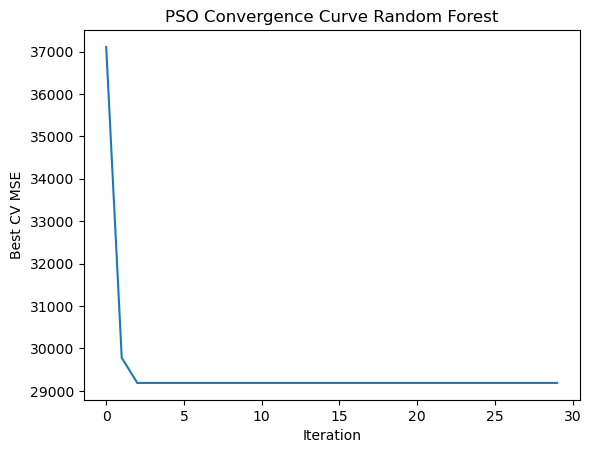

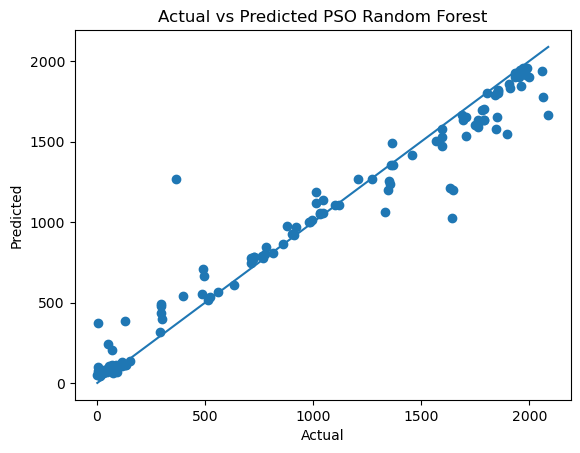

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler


# df = pd.read_excel("data_saya.xlsx")  # GANTI DENGAN FILE KAMU


X = df.drop("sisa jam", axis=1)  # ganti dengan nama target kamu
y = df["sisa jam"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

def fitness_function(particle):

    model = RandomForestRegressor(
        n_estimators=int(particle[0]),
        max_depth=int(particle[1]),
        min_samples_split=int(particle[2]),
        min_samples_leaf=int(particle[3]),
        max_features=particle[4],
        random_state=42,
        n_jobs=-1
    )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    ).mean()

    return -score  

# PSO ALGORITHM

def pso(n_particles=20, n_iterations=30, w=0.7, c1=1.5, c2=1.5):

    dim = 5

    bounds = np.array([
        [50, 300],   # n_estimators
        [2, 30],     # max_depth
        [2, 20],     # min_samples_split
        [1, 20],      # min_samples_leaf
        [0.1, 1.0]   # max_features
    ])

    particles = np.random.uniform(
        bounds[:, 0],
        bounds[:, 1],
        (n_particles, dim)
    )

    velocities = np.zeros((n_particles, dim))

    pbest_positions = particles.copy()
    pbest_scores = np.array([fitness_function(p) for p in particles])

    gbest_index = np.argmin(pbest_scores)
    gbest_position = pbest_positions[gbest_index].copy()
    gbest_score = pbest_scores[gbest_index]

    convergence_curve = []

    for iteration in range(n_iterations):

        for i in range(n_particles):

            r1, r2 = np.random.rand(), np.random.rand()

            velocities[i] = (
                w * velocities[i]
                + c1 * r1 * (pbest_positions[i] - particles[i])
                + c2 * r2 * (gbest_position - particles[i])
            )

            particles[i] += velocities[i]
            
            for d in range(dim):
                particles[i, d] = np.clip(
                    particles[i, d],
                    bounds[d, 0],
                    bounds[d, 1]
                )

            score = fitness_function(particles[i])

            if score < pbest_scores[i]:
                pbest_scores[i] = score
                pbest_positions[i] = particles[i].copy()

                if score < gbest_score:
                    gbest_score = score
                    gbest_position = particles[i].copy()

        convergence_curve.append(gbest_score)

        print(f"Iter {iteration+1}/{n_iterations} | Best CV MSE: {gbest_score:.4f}")

    return gbest_position, gbest_score, convergence_curve



best_params, best_mse, curve = pso()

print("\n=== Best Hyperparameters (PSO - Regression) ===")
print("n_estimators      :", int(best_params[0]))
print("max_depth         :", int(best_params[1]))
print("min_samples_split :", int(best_params[2]))
print("min_samples_leaf  :", int(best_params[3]))
print("max_features      :", round(best_params[4], 2))
print("Best CV MSE       :", best_mse)
print("Best CV RMSE      :", np.sqrt(best_mse))



# TRAIN FINAL MODEL

final_model = RandomForestRegressor(
    n_estimators=int(best_params[0]),
    max_depth=int(best_params[1]),
    min_samples_split=int(best_params[2]),
    min_samples_leaf=int(best_params[3]),
    max_features=best_params[4],
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n=== Final Test Evaluation (20%) ===")
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)
print("R²   :", r2)


plt.figure()
plt.plot(curve)
plt.title("PSO Convergence Curve Random Forest")
plt.xlabel("Iteration")
plt.ylabel("Best CV MSE")
plt.show()


plt.figure()
plt.scatter(y_test, y_pred)

# Garis ideal
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted PSO Random Forest")
plt.show()



### SVM/SVR

Iter 1/30 | Best CV MSE: 14529.9992
Iter 2/30 | Best CV MSE: 13331.8941
Iter 3/30 | Best CV MSE: 13247.0975
Iter 4/30 | Best CV MSE: 12866.9885
Iter 5/30 | Best CV MSE: 12146.5728
Iter 6/30 | Best CV MSE: 12101.0053
Iter 7/30 | Best CV MSE: 12071.7547
Iter 8/30 | Best CV MSE: 12051.1200
Iter 9/30 | Best CV MSE: 12051.1200
Iter 10/30 | Best CV MSE: 12051.1200
Iter 11/30 | Best CV MSE: 12051.1200
Iter 12/30 | Best CV MSE: 12051.1200
Iter 13/30 | Best CV MSE: 12051.1200
Iter 14/30 | Best CV MSE: 12051.1200
Iter 15/30 | Best CV MSE: 12050.5854
Iter 16/30 | Best CV MSE: 12050.3408
Iter 17/30 | Best CV MSE: 12050.3408
Iter 18/30 | Best CV MSE: 12049.9722
Iter 19/30 | Best CV MSE: 12049.9722
Iter 20/30 | Best CV MSE: 12049.9722
Iter 21/30 | Best CV MSE: 12049.9722
Iter 22/30 | Best CV MSE: 12049.9722
Iter 23/30 | Best CV MSE: 12049.9722
Iter 24/30 | Best CV MSE: 12049.9722
Iter 25/30 | Best CV MSE: 12049.9722
Iter 26/30 | Best CV MSE: 12049.9722
Iter 27/30 | Best CV MSE: 12049.9722
Iter 28/30

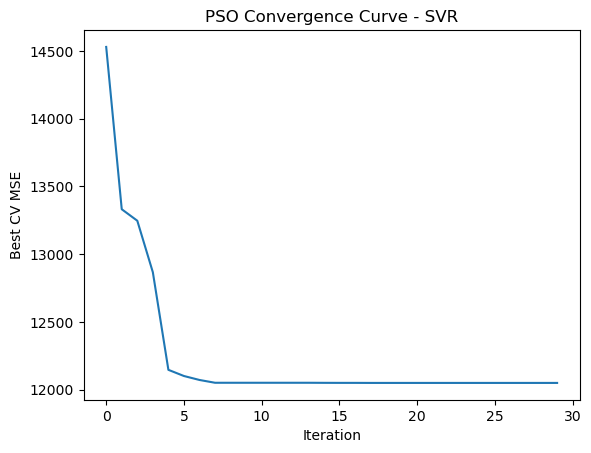

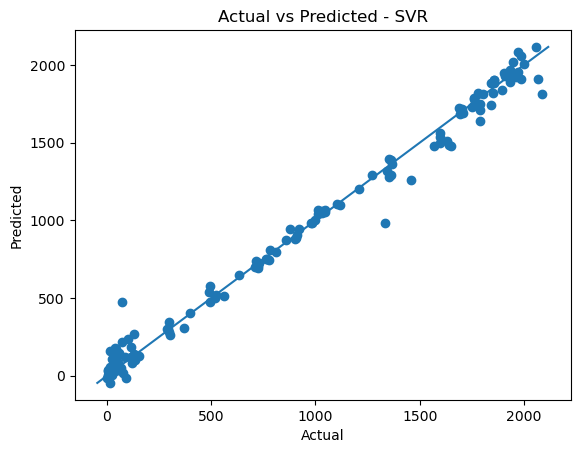

In [ ]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline


X = df.drop("sisa jam", axis=1)
y = df["sisa jam"]


# X = X.apply(pd.to_numeric, errors='coerce')
# y = pd.to_numeric(y, errors='coerce')


# data_clean = pd.concat([X, y], axis=1).dropna()
# X = data_clean.drop("sisa jam", axis=1)
# y = data_clean["sisa jam"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

def fitness_function(particle):

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR(
            kernel='rbf',
            C=particle[0],
            epsilon=particle[1],
            gamma=particle[2]
        ))
    ])

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    ).mean()

    return -score



def pso(n_particles=20, n_iterations=30, w=0.7, c1=1.5, c2=1.5):

    dim = 3

    bounds = np.array([
        [0.1, 1000],     # C
        [0.001, 50],     # epsilon
        [0.0001, 1]    # gamma
    ])

    particles = np.random.uniform(
        bounds[:, 0],
        bounds[:, 1],
        (n_particles, dim)
    )

    velocities = np.zeros((n_particles, dim))

    pbest_positions = particles.copy()
    pbest_scores = np.array([fitness_function(p) for p in particles])

    gbest_index = np.argmin(pbest_scores)
    gbest_position = pbest_positions[gbest_index].copy()
    gbest_score = pbest_scores[gbest_index]

    convergence_curve = []

    for iteration in range(n_iterations):

        for i in range(n_particles):

            r1, r2 = np.random.rand(), np.random.rand()

            velocities[i] = (
                w * velocities[i]
                + c1 * r1 * (pbest_positions[i] - particles[i])
                + c2 * r2 * (gbest_position - particles[i])
            )

            particles[i] += velocities[i]

            for d in range(dim):
                particles[i, d] = np.clip(
                    particles[i, d],
                    bounds[d, 0],
                    bounds[d, 1]
                )

            score = fitness_function(particles[i])

            if score < pbest_scores[i]:
                pbest_scores[i] = score
                pbest_positions[i] = particles[i].copy()

                if score < gbest_score:
                    gbest_score = score
                    gbest_position = particles[i].copy()

        convergence_curve.append(gbest_score)

        print(f"Iter {iteration+1}/{n_iterations} | Best CV MSE: {gbest_score:.4f}")

    return gbest_position, gbest_score, convergence_curve



# RUN PSO

best_params, best_mse, curve = pso()

print("\n=== Best Hyperparameters (PSO - SVR) ===")
print("C        :", best_params[0])
print("epsilon  :", best_params[1])
print("gamma    :", best_params[2])
print("Best CV MSE  :", best_mse)
print("Best CV RMSE :", np.sqrt(best_mse))



# TRAIN FINAL MODEL

final_model = SVR(
    kernel='rbf',
    C=best_params[0],
    epsilon=best_params[1],
    gamma=best_params[2]
)

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)


# EVALUASI TEST

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n=== Final Test Evaluation (20%) ===")
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)
print("R²   :", r2)



plt.figure()
plt.plot(curve)
plt.title("PSO Convergence Curve - SVR")
plt.xlabel("Iteration")
plt.ylabel("Best CV MSE")
plt.show()



plt.figure()
plt.scatter(y_test, y_pred)

min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted - SVR")
plt.show()
